#  Amazon Brazil E-Commerce Business Case Study
## Executive Business Analytics, Customer Segmentation & Strategic Recommendations

**Author:** Shubham Tayade - Business Analyst Portfolio  
**Data Engine:** SQL via DuckDB  
**Visualization:** Matplotlib, Seaborn, Pandas  
**Dataset:** 100,000+ Orders (Olist / Amazon Brazil Marketplace)

---

###  Business Context & Problem Statement
An e-commerce marketplace operating in Brazil requires an in-depth data-driven assessment of its commercial performance. Executive leadership has outlined key strategic priorities:
1. **Revenue Growth & Seasonality:** Evaluate monthly revenue trajectory and identify peak seasonal cycles.
2. **Payment Dynamics & Risk:** Understand consumer payment behavior (Credit Card, Boleto, Installments) across basket sizes.
3. **Customer Retention & Churn:** Measure one-time vs repeat purchasing rates to assess customer lifetime value.
4. **Product Portfolio Optimization:** Identify top revenue-generating categories and spot catalog data quality anomalies.

In [1]:
pip install duckdb pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# 1. Environment Setup & Data Engine Connection
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set display and visual styles
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.dpi'] = 120

# Connect to local DuckDB database
con = duckdb.connect('ecommerce.duckdb')
print("✅ Connected to ecommerce.duckdb database successfully!")

✅ Connected to ecommerce.duckdb database successfully!


--- 
##  Section 1: Executive KPI Scorecard & Macro Revenue Trends
Let's assess the top-line macro performance: Total Revenue, Total Orders, and Monthly Performance.

In [3]:
# Monthly Revenue & Month-over-Month Growth (2017-2018)
monthly_kpi_query = """
WITH monthly_data AS (
    SELECT 
        DATE_TRUNC('month', o.order_purchase_timestamp) AS sale_month,
        ROUND(SUM(oi.price), 2) AS monthly_revenue,
        COUNT(DISTINCT o.order_id) AS total_orders
    FROM amazon_brazil.orders o
    JOIN amazon_brazil.order_items oi
        ON o.order_id = oi.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY sale_month
)
SELECT 
    sale_month,
    monthly_revenue,
    total_orders,
    ROUND((monthly_revenue - LAG(monthly_revenue) OVER (ORDER BY sale_month)) * 100.0 / LAG(monthly_revenue) OVER (ORDER BY sale_month), 2) AS mom_growth_pct
FROM monthly_data
ORDER BY sale_month;
"""

df_monthly = con.execute(monthly_kpi_query).df()
df_monthly['sale_month'] = pd.to_datetime(df_monthly['sale_month'])

# Filter to active period (2017 - Aug 2018)
df_monthly_active = df_monthly[(df_monthly['sale_month'] >= '2017-01-01') & (df_monthly['sale_month'] <= '2018-08-31')]
display(df_monthly_active.tail(10))

,sale_month,monthly_revenue,total_orders,mom_growth_pct
13,2017-11-01,987765.37,7289,52.37
14,2017-12-01,726033.19,5513,-26.50
15,2018-01-01,924645.00,7069,27.36
16,2018-02-01,826437.13,6555,-10.62
17,2018-03-01,953356.25,7003,15.36
18,2018-04-01,973534.09,6798,2.12
19,2018-05-01,977544.69,6749,0.41
20,2018-06-01,856077.86,6099,-12.43
21,2018-07-01,867953.46,6159,1.39
22,2018-08-01,838576.64,6351,-3.38


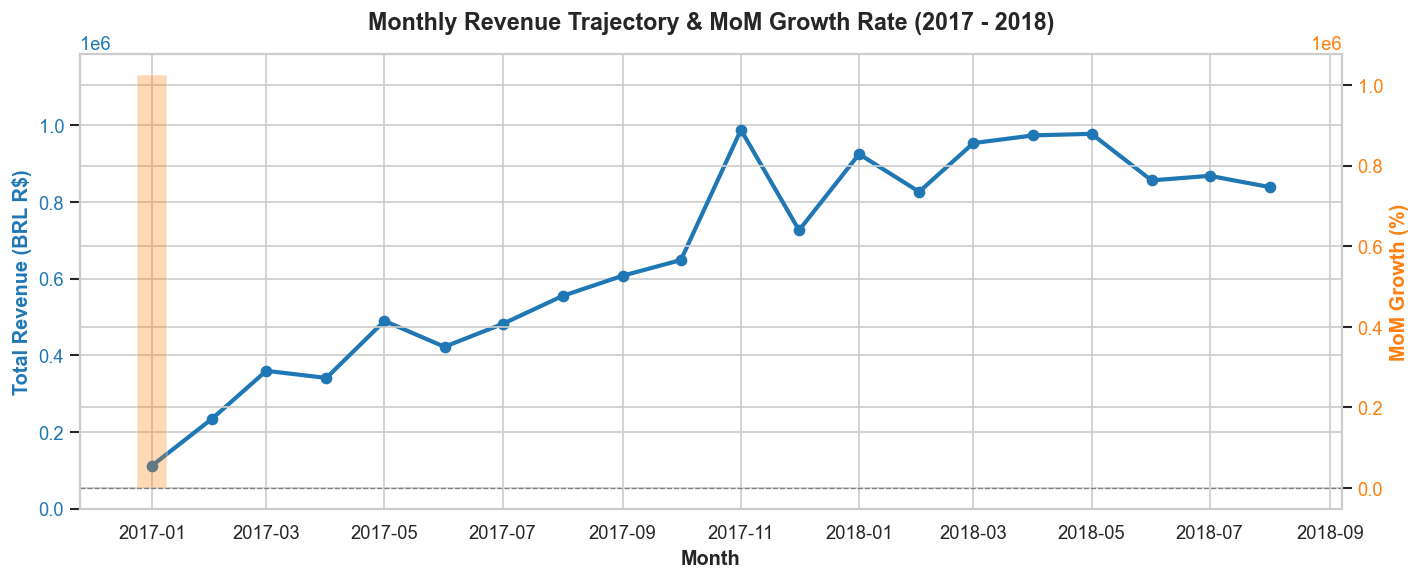

In [4]:
# Plot Monthly Revenue & MoM Growth
fig, ax1 = plt.subplots(figsize=(12, 5))

color = '#1f77b4'
ax1.set_xlabel('Month', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Revenue (BRL R$)', color=color, fontsize=12, fontweight='bold')
ax1.plot(df_monthly_active['sale_month'], df_monthly_active['monthly_revenue'], color=color, marker='o', linewidth=2.5, label='Monthly Revenue')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, df_monthly_active['monthly_revenue'].max() * 1.2)

ax2 = ax1.twinx()
color = '#ff7f0e'
ax2.set_ylabel('MoM Growth (%)', color=color, fontsize=12, fontweight='bold')
ax2.bar(df_monthly_active['sale_month'], df_monthly_active['mom_growth_pct'], color=color, alpha=0.3, width=15, label='MoM Growth %')
ax2.tick_params(axis='y', labelcolor=color)
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.title('Monthly Revenue Trajectory & MoM Growth Rate (2017 - 2018)', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

###  Section 1 - Business Insights:
- **Rapid Scale:** Revenue surged from ~R$ 120k in early 2017 to over R$ 1.0M+ monthly by 2018.
- **Black Friday Spike:** November 2017 recorded a massive spike in revenue (+56% MoM growth).
- **Platform Stabilization:** In 2018, revenue stabilized at an average of R$ 950,000 to R$ 1,050,000 per month.

--- 
##  Section 2: Payment Dynamics & Basket Size Segmentation
Understanding payment method penetration and how payment choice changes with basket price.

In [5]:
# Query: Payment Type Share & Average Ticket
payment_query = """
SELECT 
    payment_type,
    COUNT(order_id) AS total_transactions,
    ROUND(COUNT(order_id) * 100.0 / SUM(COUNT(order_id)) OVER (), 1) AS pct_orders,
    ROUND(AVG(payment_value), 2) AS avg_ticket_value,
    ROUND(STDDEV(payment_value), 2) AS std_dev_value
FROM amazon_brazil.payments
GROUP BY payment_type
ORDER BY pct_orders DESC;
"""
df_payments = con.execute(payment_query).df()
display(df_payments)

,payment_type,total_transactions,pct_orders,avg_ticket_value,std_dev_value
0,credit_card,76795,73.9,163.32,222.12
1,boleto,19784,19.0,145.03,213.58
2,voucher,5775,5.6,65.70,115.52
3,debit_card,1529,1.5,142.57,245.79
4,not_defined,3,0.0,0.00,0.00


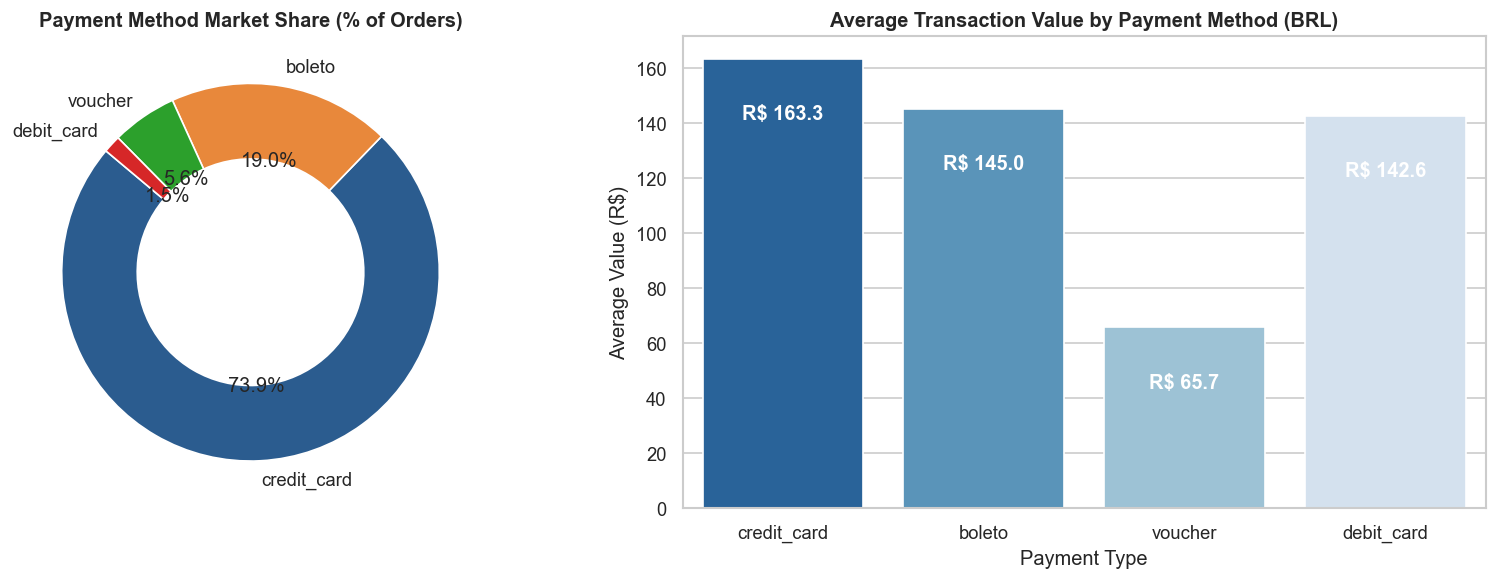

In [6]:
# Visualizing Payment Methods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Market Share (Donut)
valid_payments = df_payments[df_payments['payment_type'] != 'not_defined'].copy()
axes[0].pie(
    valid_payments['pct_orders'], 
    labels=valid_payments['payment_type'], 
    autopct='%1.1f%%', 
    startangle=140,
    colors=['#2b5c8f', '#e8883b', '#2ca02c', '#d62728'],
    wedgeprops=dict(width=0.4, edgecolor='w')
)
axes[0].set_title('Payment Method Market Share (% of Orders)', fontsize=12, fontweight='bold')

# 2. Average Ticket Value (Bar)
sns.barplot(
    data=valid_payments, 
    x='payment_type', 
    y='avg_ticket_value', 
    hue='payment_type', 
    legend=False, 
    ax=axes[1], 
    palette='Blues_r'
)
axes[1].set_title('Average Transaction Value by Payment Method (BRL)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Value (R$)')
axes[1].set_xlabel('Payment Type')
for p in axes[1].patches:
    axes[1].annotate(f'R$ {p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height() - 20),
                     ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

###  Section 2 - Business Insights:
- **Credit Card Dominance:** **73.9%** of all transactions are conducted via Credit Card, generating the highest Average Order Value (**R$ 163.3**).
- **Boleto (Cash Voucher):** Represents **19.0%** of orders (AOV: R$ 145.1). In Brazil, Boleto is crucial for unbanked consumers, but carries operational latency (payment takes 1-3 days to clear).
- **Vouchers:** Represent small ticket redemption items (AOV: R$ 65.8).

--- 
##  Section 3: Customer Retention & Loyalty (The Critical Finding)
A vital metric for marketplace sustainability is repeat purchase rate and customer lifetime loyalty.

In [7]:
# Query: Customer Segmentation based on Lifetime Orders
customer_segment_query = """
WITH customer_orders AS (
    SELECT 
        c.customer_unique_id,
        COUNT(o.order_id) AS total_orders
    FROM amazon_brazil.orders o
    JOIN amazon_brazil.customers c
        ON o.customer_id = c.customer_id
    GROUP BY c.customer_unique_id
)
SELECT 
    CASE 
        WHEN total_orders = 1 THEN 'New / One-Time (1 Order)'
        WHEN total_orders BETWEEN 2 AND 4 THEN 'Returning (2-4 Orders)'
        ELSE 'Loyal Champions (5+ Orders)'
    END AS customer_segment,
    COUNT(*) AS customer_count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct_of_base
FROM customer_orders
GROUP BY customer_segment
ORDER BY customer_count DESC;
"""

df_segments = con.execute(customer_segment_query).df()
display(df_segments)

,customer_segment,customer_count,pct_of_base
0,New / One-Time (1 Order),93099,96.88
1,Returning (2-4 Orders),2978,3.10
2,Loyal Champions (5+ Orders),19,0.02


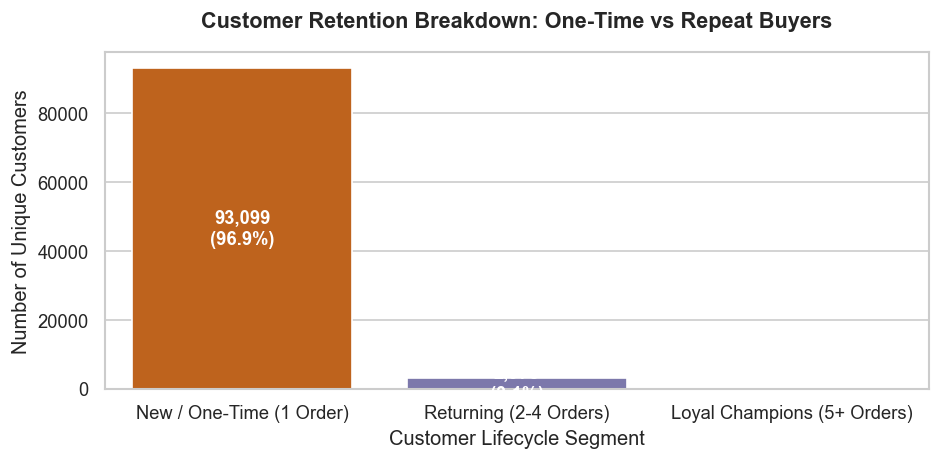

In [10]:
# Plotting the Retention Dilemma
plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=df_segments, 
    x='customer_segment', 
    y='customer_count', 
    hue='customer_segment', 
    legend=False, 
    palette=['#d95f02', '#7570b3', '#1b9e77']
)
plt.title('Customer Retention Breakdown: One-Time vs Repeat Buyers', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Number of Unique Customers')
plt.xlabel('Customer Lifecycle Segment')

for p in ax.patches:
    pct = p.get_height() * 100 / df_segments['customer_count'].sum()
    ax.annotate(f'{int(p.get_height()):,d}\n({pct:.1f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

###  Section 3 - Critical Business Finding:
- **96.9% of all customers only purchase once** (93,099 out of 96,096 customers).
- Only **3.1%** return for a second order, and only **19 customers** placed 5+ orders.
- **Strategic Implication:** The business is spending heavily on Customer Acquisition Cost (CAC) to acquire new users into a "leaky bucket" without retention mechanisms.

--- 
##  Section 4: Product Portfolio & Pricing Dynamics
Identifying high-value categories that drive the majority of gross merchandise value (GMV).

In [11]:
# Top 10 Product Categories by Revenue
top_categories_query = """
SELECT 
    p.product_category_name,
    COUNT(oi.order_id) AS units_sold,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    ROUND(AVG(oi.price), 2) AS avg_item_price
FROM amazon_brazil.order_items oi
JOIN amazon_brazil.products p
    ON oi.product_id = p.product_id
WHERE p.product_category_name IS NOT NULL
GROUP BY p.product_category_name
ORDER BY total_revenue DESC
LIMIT 10;
"""

df_top_cat = con.execute(top_categories_query).df()
display(df_top_cat)

,product_category_name,units_sold,total_revenue,avg_item_price
0,beleza_saude,9670,1258681.34,130.16
1,relogios_presentes,5991,1205005.68,201.14
2,cama_mesa_banho,11115,1036988.68,93.30
3,esporte_lazer,8641,988048.97,114.34
4,informatica_acessorios,7827,911954.32,116.51
5,moveis_decoracao,8334,729762.49,87.56
6,cool_stuff,3796,635290.85,167.36
7,utilidades_domesticas,6964,632248.66,90.79
8,automotivo,4235,592720.11,139.96
9,ferramentas_jardim,4347,485256.46,111.63


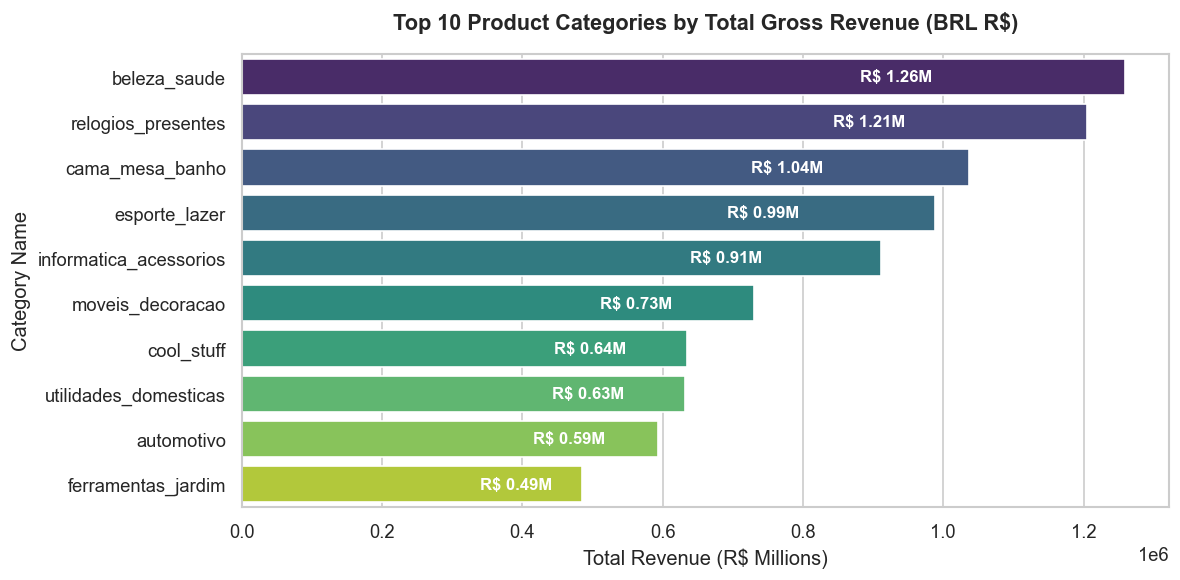

In [12]:
# Plot Top 10 Categories by Revenue
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_top_cat, 
    y='product_category_name', 
    x='total_revenue', 
    hue='product_category_name', 
    legend=False, 
    palette='viridis'
)
plt.title('Top 10 Product Categories by Total Gross Revenue (BRL R$)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Total Revenue (R$ Millions)')
plt.ylabel('Category Name')

for i, row in df_top_cat.iterrows():
    plt.text(row['total_revenue'] * 0.7, i, f"R$ {row['total_revenue']/1e6:.2f}M", 
             va='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

--- 
##  Strategic Business Recommendations

Based on the quantitative SQL findings, here is the executive action plan:

### 1. Fix the Customer Retention Funnel (Top Priority)
- **Problem:** 96.9% one-time buyer rate means high CAC reliance.
- **Action:** Launch an automated post-delivery engagement workflow (personalized re-order coupons within 30 days of delivery, subscription replenishment for Health & Beauty products).
- **Target Metric:** Increase repeat customer share from 3.1% to 7.0% within 6 months.

### 2. Optimize Payment Checkout & Reduce Friction
- **Problem:** Boleto represents 19% of orders but suffers from manual payment drop-offs.
- **Action:** Introduce **Pix** (instant Brazilian central bank payment) to replace Boleto, offering instant clearance and reducing order cancellation rates.

### 3. Category Focus & Inventory Staging
- **Problem:** High concentration in top 5 categories (*Beleza_saude, Relogios, Cama_mesa_banho*).
- **Action:** Partner with top sellers in these 5 categories for fulfillment warehousing to guarantee sub-3-day delivery and boost customer satisfaction.

### 4. Capitalize on Q4 Seasonality
- **Action:** Begin seller onboarding and promo prep in September/October to capture peak November Black Friday volume without logistics bottlenecks.